In [26]:
import sys
sys.path.insert(0, "..")

# Data Exploration

In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from datetime import datetime
from warnings import filterwarnings
import logging

matplotlib.rc("font", **{"size": 14})
logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s")
filterwarnings("ignore")

from src.data.option_db import SPYOptionLoader, AAPLOptionLoader, extract_spot_from_options
from src.data.rates_db import USRatesLoader
from src.trading.selection import select_options, select_closest_maturity

## 1. Loading the Data

In [29]:
START_DATE = datetime(2020, 1, 2)
END_DATE   = datetime(2022, 12, 30)

df_spy = SPYOptionLoader.load_data(
    start_date=START_DATE,
    end_date=END_DATE,
    process_kwargs={"ticker": "SPY"},
)
df_spy.head()

2026-03-29 11:19:38,999 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from C:\Users\Marius\PycharmProjects\Volatility-Trading-Project--Dispersion-Strategies\data\spy_2020_2022.parquet with None
2026-03-29 11:19:39,324 | INFO | Processing with {'ticker': 'SPY'}
2026-03-29 11:19:39,325 | INFO | Potentially add extra field with None


,date,spot,strike,expiration,delta,gamma,vega,theta,rho,implied_volatility,bid,ask,volume,call_put,option_id,mid,ticker,day_to_expiration,moneyness
0,2021-09-01,451.85,270.0,2021-09-01,1.0,0.0,0.0,0.0,0.00517,0.0,181.85,181.85,1.0,C,SPY 20210901C270,181.85,SPY,0,0.597543
1,2021-09-01,451.85,275.0,2021-09-01,1.0,0.0,0.0,0.0,0.00527,0.0,176.85,176.85,0.0,C,SPY 20210901C275,176.85,SPY,0,0.608609
2,2021-09-01,451.85,280.0,2021-09-01,1.0,0.0,0.0,0.0,0.00569,0.0,171.85,171.85,25.0,C,SPY 20210901C280,171.85,SPY,0,0.619675
3,2021-09-01,451.85,285.0,2021-09-01,1.0,0.0,0.0,0.0,0.00530,0.0,166.85,166.85,25.0,C,SPY 20210901C285,166.85,SPY,0,0.630740
4,2021-09-01,451.85,290.0,2021-09-01,1.0,0.0,0.0,0.0,0.00534,0.0,161.85,161.85,25.0,C,SPY 20210901C290,161.85,SPY,0,0.641806


In [30]:
df_aapl = AAPLOptionLoader.load_data(
    start_date=START_DATE,
    end_date=END_DATE,
    process_kwargs={"ticker": "AAPL"},
)
df_aapl.head()

2026-03-29 11:19:41,564 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from C:\Users\Marius\PycharmProjects\Volatility-Trading-Project--Dispersion-Strategies\data\aapl_2016_2023.parquet with None
2026-03-29 11:19:41,729 | INFO | Processing with {'ticker': 'AAPL'}
2026-03-29 11:19:41,730 | INFO | Potentially add extra field with None


,date,spot,strike,expiration,delta,gamma,vega,theta,rho,implied_volatility,bid,ask,volume,call_put,option_id,mid,ticker,day_to_expiration,moneyness
16690,2020-11-02,108.77,60.0,2020-11-06,1.0,0.0,0.0,0.0,0.0,0.0,48.34,48.60,7.0,C,AAPL 20201106C60,48.470,AAPL,4,0.551623
16691,2020-11-02,108.77,65.0,2020-11-06,1.0,0.0,0.0,0.0,0.0,0.0,43.46,43.65,9.0,C,AAPL 20201106C65,43.555,AAPL,4,0.597591
16692,2020-11-02,108.77,70.0,2020-11-06,1.0,0.0,0.0,0.0,0.0,0.0,38.30,38.50,3.0,C,AAPL 20201106C70,38.400,AAPL,4,0.643560
16693,2020-11-02,108.77,71.0,2020-11-06,1.0,0.0,0.0,0.0,0.0,0.0,37.34,37.55,0.0,C,AAPL 20201106C71,37.445,AAPL,4,0.652754
16694,2020-11-02,108.77,72.0,2020-11-06,1.0,0.0,0.0,0.0,0.0,0.0,36.41,36.60,0.0,C,AAPL 20201106C72,36.505,AAPL,4,0.661947


In [31]:
df_rates = USRatesLoader.load_data(start_date=START_DATE, end_date=END_DATE)
df_rates.head()

2026-03-29 11:19:45,100 | INFO | Reading between 2020-01-02 00:00:00 2022-12-30 00:00:00 from C:\Users\Marius\PycharmProjects\Volatility-Trading-Project--Dispersion-Strategies\data\par-yield-curve-rates-2020-2023.csv with None
2026-03-29 11:19:45,114 | INFO | Processing with None
2026-03-29 11:19:45,114 | INFO | Potentially add extra field with None


,date,1 Mo,2 Mo,3 Mo,4 Mo,6 Mo,1 Yr,2 Yr,3 Yr,5 Yr,7 Yr,10 Yr,20 Yr,30 Yr
0,2020-01-02,0.0153,0.0155,0.0154,NaN,0.0157,0.0156,0.0158,0.0159,0.0167,0.0179,0.0188,0.0219,0.0233
1,2020-01-03,0.0152,0.0155,0.0152,NaN,0.0155,0.0155,0.0153,0.0154,0.0159,0.0171,0.0180,0.0211,0.0226
2,2020-01-06,0.0154,0.0154,0.0156,NaN,0.0156,0.0154,0.0154,0.0156,0.0161,0.0172,0.0181,0.0213,0.0228
3,2020-01-07,0.0152,0.0153,0.0154,NaN,0.0156,0.0153,0.0154,0.0155,0.0162,0.0174,0.0183,0.0216,0.0231
4,2020-01-08,0.0150,0.0153,0.0154,NaN,0.0156,0.0155,0.0158,0.0161,0.0167,0.0178,0.0187,0.0221,0.0235


In [32]:
print(f"SPY options : {df_spy.shape}   | dates: {df_spy['date'].min().date()} → {df_spy['date'].max().date()}")
print(f"AAPL options: {df_aapl.shape}  | dates: {df_aapl['date'].min().date()} → {df_aapl['date'].max().date()}")
print(f"US Rates    : {df_rates.shape} | dates: {df_rates['date'].min().date()} → {df_rates['date'].max().date()}")

SPY options : (7178158, 19)   | dates: 2020-01-02 → 2022-12-30
AAPL options: (1537148, 19)  | dates: 2020-01-02 → 2022-12-30
US Rates    : (751, 14) | dates: 2020-01-02 → 2022-12-30


## 2. Spot Prices

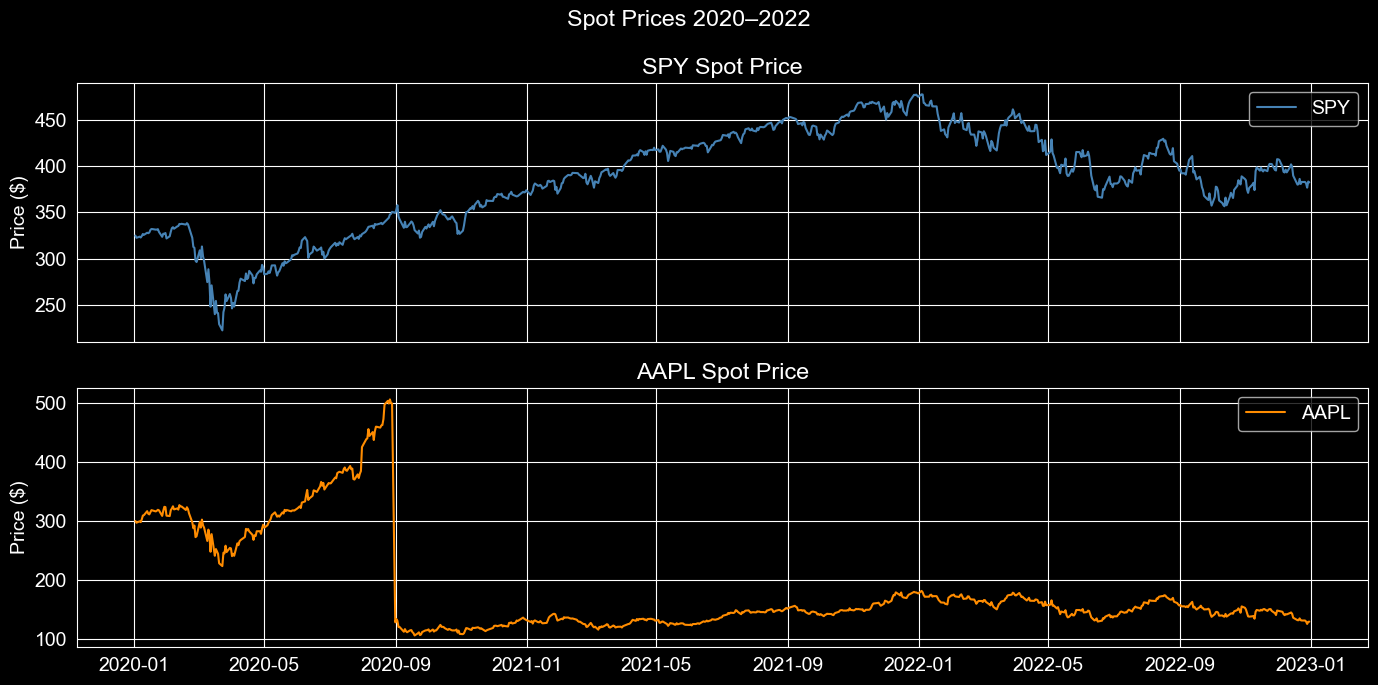

In [33]:
df_spy_spot  = extract_spot_from_options(df_spy)
df_aapl_spot = extract_spot_from_options(df_aapl)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(df_spy_spot["date"],  df_spy_spot["spot"],  label="SPY",  color="steelblue")
axes[0].set_title("SPY Spot Price"); axes[0].set_ylabel("Price ($)"); axes[0].legend()
axes[1].plot(df_aapl_spot["date"], df_aapl_spot["spot"], label="AAPL", color="darkorange")
axes[1].set_title("AAPL Spot Price"); axes[1].set_ylabel("Price ($)"); axes[1].legend()
fig.suptitle("Spot Prices 2020–2022"); plt.tight_layout(); plt.show()

## 3. Implied Volatility — Surface Snapshots

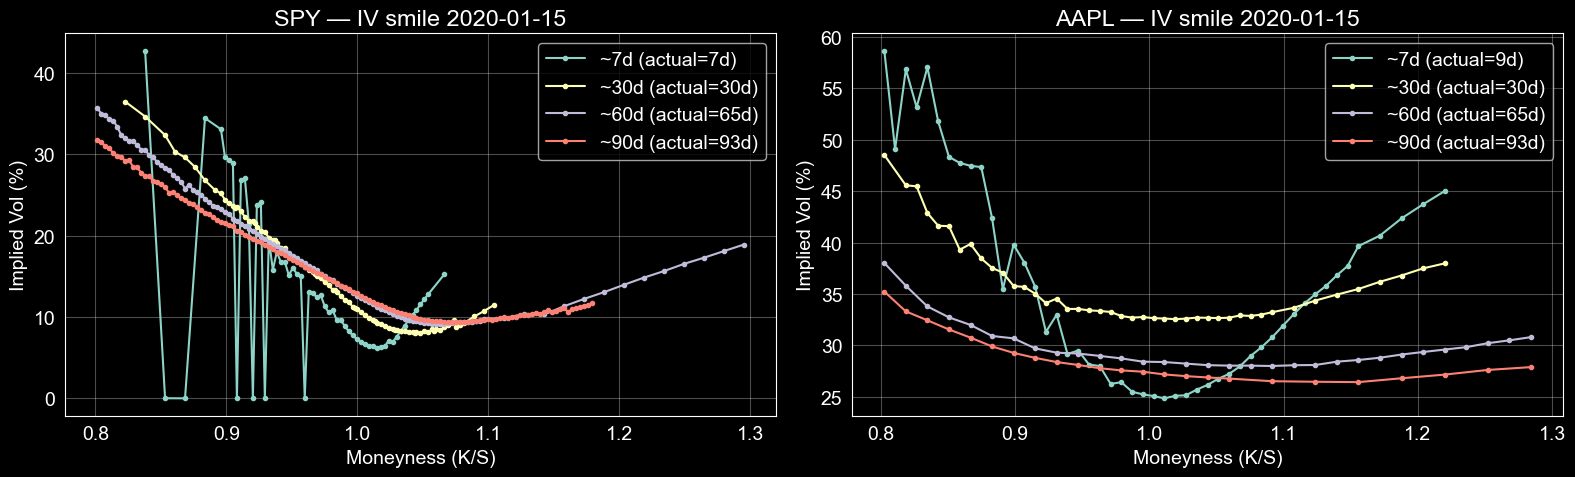

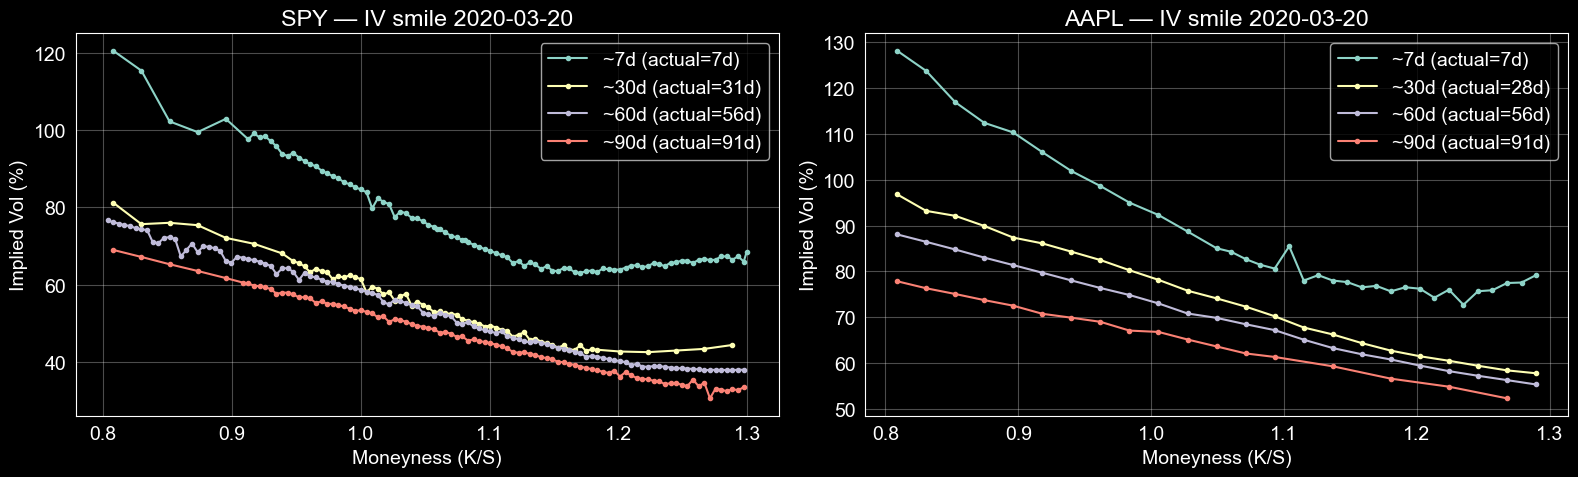

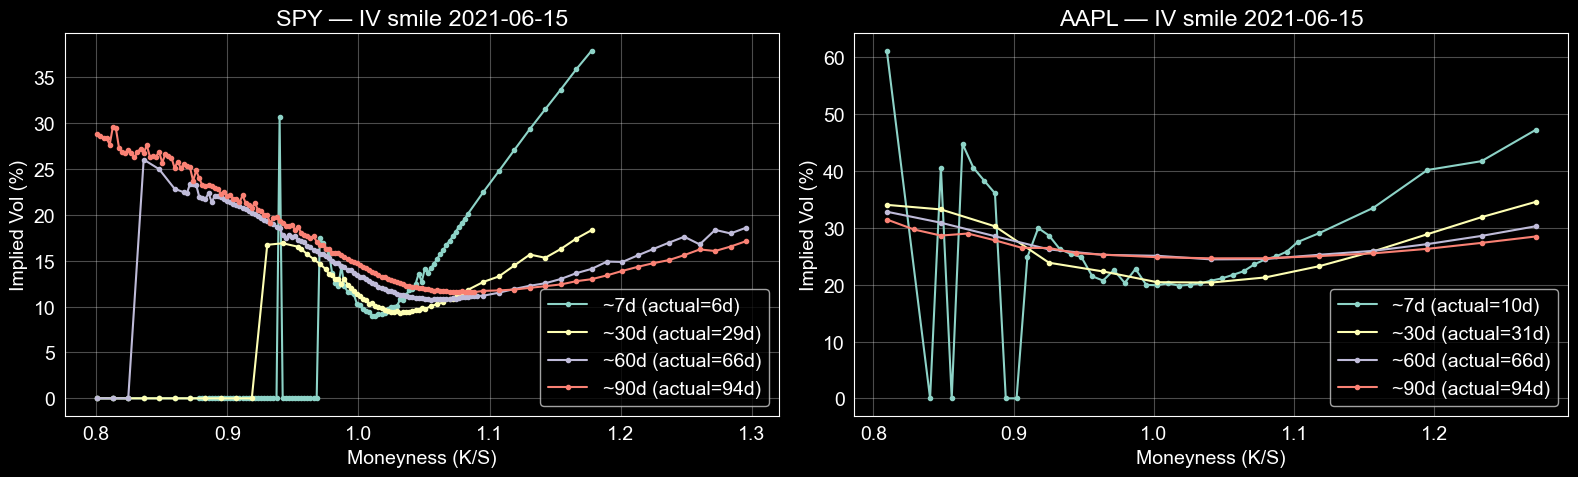

In [34]:
REF_DATES = [datetime(2020, 1, 15), datetime(2020, 3, 20), datetime(2021, 6, 15)]
MATURITY_TARGETS = [7, 30, 60, 90]

for ref_date in REF_DATES:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=False)
    for ax, (df, ticker) in zip(axes, [(df_spy, "SPY"), (df_aapl, "AAPL")]):
        df_day = df[(df["date"] == ref_date) & (df["call_put"] == "C")].copy()
        for dte in MATURITY_TARGETS:
            # Use select_closest_maturity to pick ONE expiry per DTE target
            df_day_dte = select_closest_maturity(
                df_day, day_to_expiry_target=dte
            )
            # Keep unique expiry (tie-break: prefer shorter DTE)
            if len(df_day_dte) == 0:
                continue
            best_exp = df_day_dte.drop_duplicates("expiration").sort_values("day_to_expiration").iloc[0]["expiration"]
            bucket = df_day_dte[df_day_dte["expiration"] == best_exp].copy()
            # Filter moneyness range and cap extreme IV values
            bucket = bucket[(bucket["moneyness"] >= 0.8) & (bucket["moneyness"] <= 1.3)].sort_values("moneyness")
            bucket = bucket[bucket["implied_volatility"] < 3.0]  # cap at 300%
            if len(bucket) > 2:
                actual_dte = int(bucket["day_to_expiration"].iloc[0])
                ax.plot(bucket["moneyness"], bucket["implied_volatility"] * 100,
                        label=f"~{dte}d (actual={actual_dte}d)", marker="o", markersize=3)
        ax.set_title(f"{ticker} — IV smile {ref_date.date()}")
        ax.set_xlabel("Moneyness (K/S)"); ax.set_ylabel("Implied Vol (%)")
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


## 4. ATM IV Term Structure Over Time

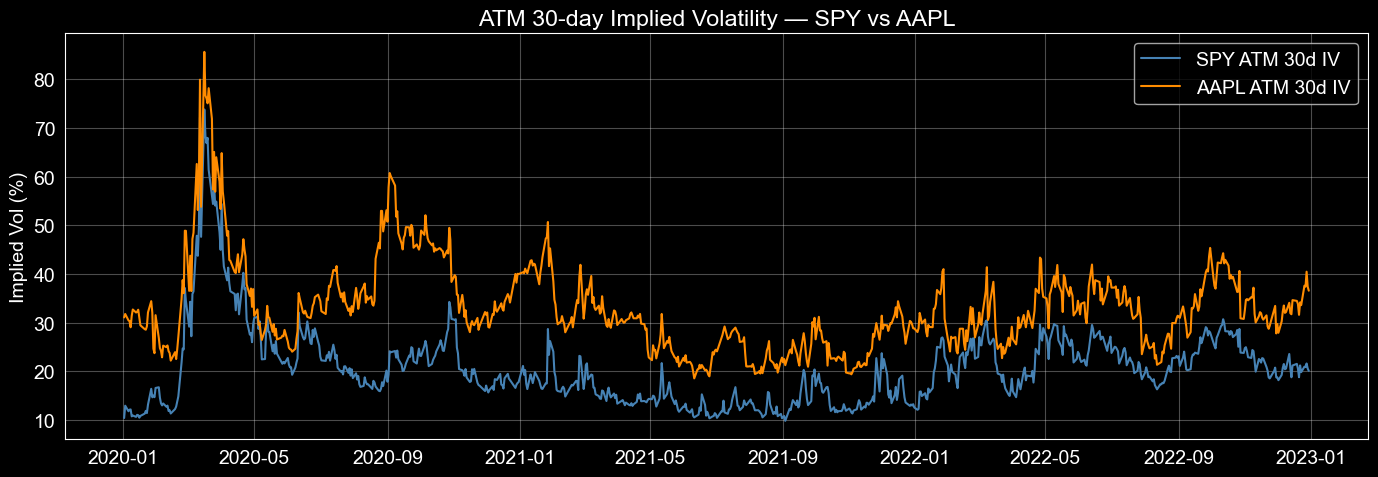

In [35]:
df_spy_atm_30 = select_options(
    df_spy,
    call_or_put="C",
    strike_col="moneyness",
    strike_target=1.0,
    day_to_expiry_target=30,
)
# Fix: sort by date, then keep only one row per date (tie-break on closest moneyness)
df_spy_atm_30 = (
    df_spy_atm_30
    .assign(_dist=lambda x: abs(x["moneyness"] - 1.0))
    .sort_values(["date", "_dist"])
    .drop_duplicates(subset=["date"], keep="first")
    .drop(columns=["_dist"])
    .sort_values("date")
    .reset_index(drop=True)
)

df_aapl_atm_30 = select_options(
    df_aapl,
    call_or_put="C",
    strike_col="moneyness",
    strike_target=1.0,
    day_to_expiry_target=30,
)
df_aapl_atm_30 = (
    df_aapl_atm_30
    .assign(_dist=lambda x: abs(x["moneyness"] - 1.0))
    .sort_values(["date", "_dist"])
    .drop_duplicates(subset=["date"], keep="first")
    .drop(columns=["_dist"])
    .sort_values("date")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_spy_atm_30["date"],  df_spy_atm_30["implied_volatility"]  * 100,
        label="SPY ATM 30d IV",  color="steelblue")
ax.plot(df_aapl_atm_30["date"], df_aapl_atm_30["implied_volatility"] * 100,
        label="AAPL ATM 30d IV", color="darkorange")
ax.set_title("ATM 30-day Implied Volatility — SPY vs AAPL")
ax.set_ylabel("Implied Vol (%)"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


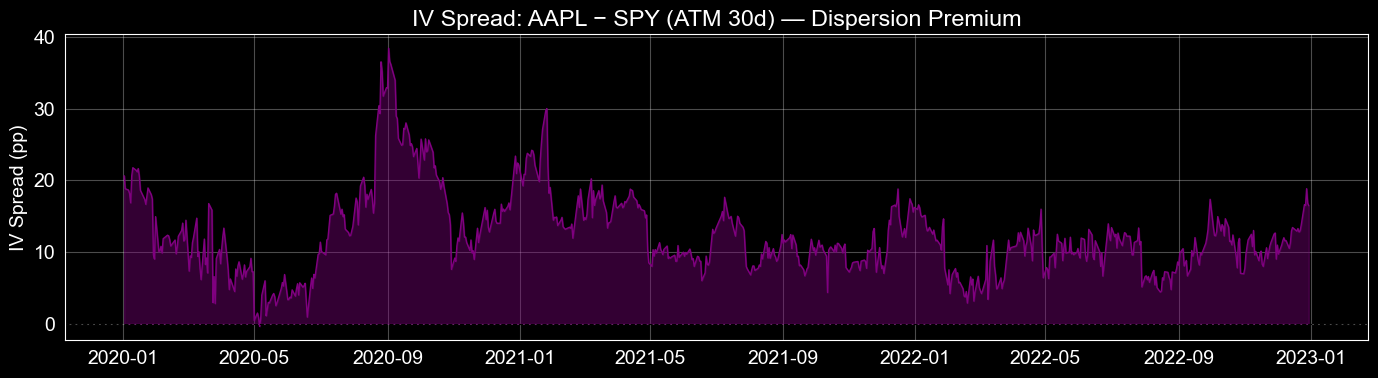

In [36]:
# Merge on common dates to avoid index misalignment
df_spy_iv = df_spy_atm_30[["date", "implied_volatility"]].rename(columns={"implied_volatility": "spy_iv"})
df_aapl_iv = df_aapl_atm_30[["date", "implied_volatility"]].rename(columns={"implied_volatility": "aapl_iv"})
df_iv_spread = df_spy_iv.merge(df_aapl_iv, on="date", how="inner").sort_values("date")
df_iv_spread["iv_spread"] = (df_iv_spread["aapl_iv"] - df_iv_spread["spy_iv"]) * 100

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(df_iv_spread["date"], df_iv_spread["iv_spread"], alpha=0.4, color="purple")
ax.plot(df_iv_spread["date"], df_iv_spread["iv_spread"], color="purple", linewidth=1)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("IV Spread: AAPL − SPY (ATM 30d) — Dispersion Premium")
ax.set_ylabel("IV Spread (pp)"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 5. Greeks Over Time — θ, Γ, ν (ATM 30d)

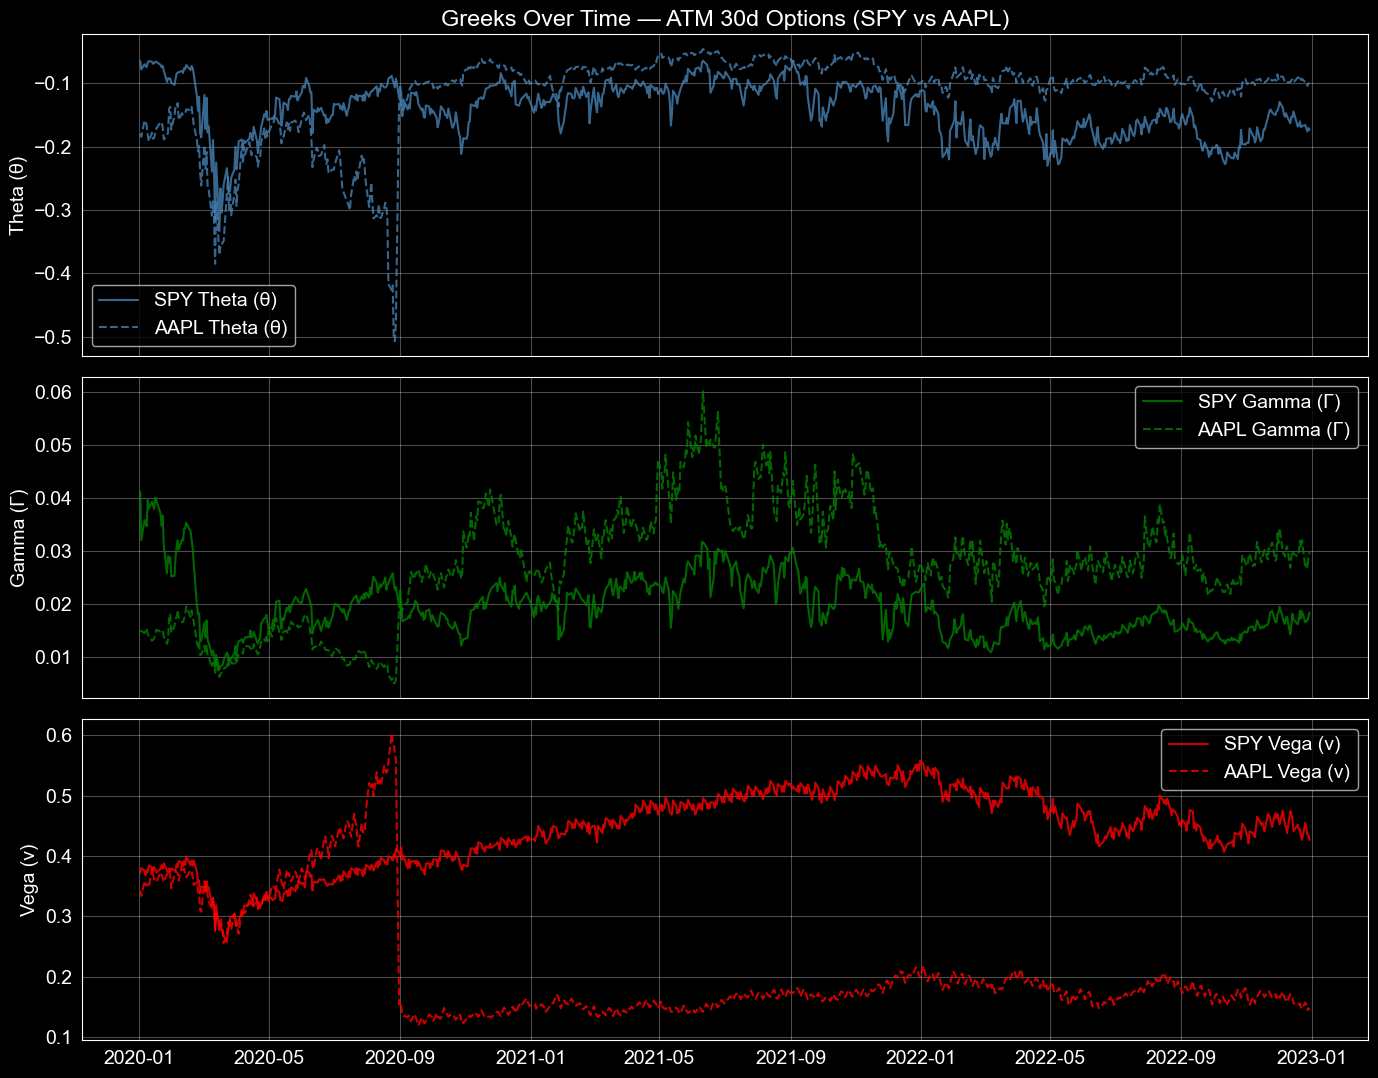

In [37]:
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
greek_labels = [
    ("theta", "Theta (θ)", "steelblue"),
    ("gamma", "Gamma (Γ)", "green"),
    ("vega",  "Vega (ν)",  "red"),
]

for ax, (greek, label, color) in zip(axes, greek_labels):
    ax.plot(df_spy_atm_30["date"],  df_spy_atm_30[greek],
            label=f"SPY {label}",  color=color, alpha=0.8)
    ax.plot(df_aapl_atm_30["date"], df_aapl_atm_30[greek],
            label=f"AAPL {label}", color=color, linestyle="--", alpha=0.8)
    ax.set_ylabel(label); ax.legend(); ax.grid(True, alpha=0.3)
axes[0].set_title("Greeks Over Time — ATM 30d Options (SPY vs AAPL)")
plt.tight_layout(); plt.show()


## 6. Bid-Ask Spread Analysis

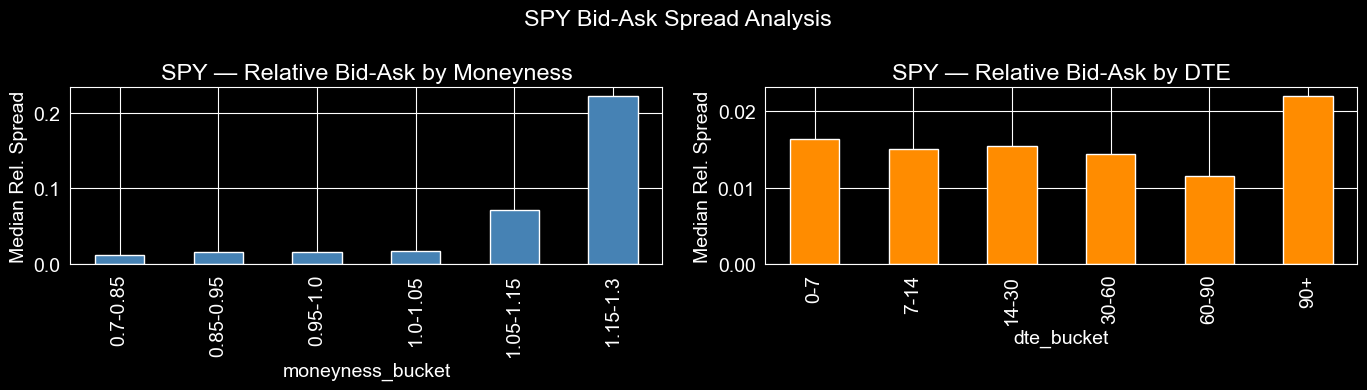

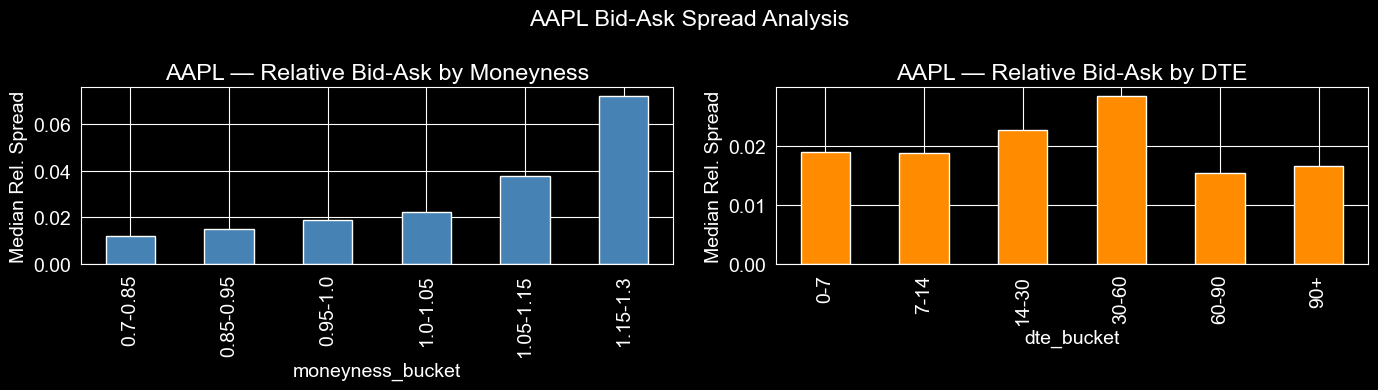

In [38]:
for df, ticker in [(df_spy, "SPY"), (df_aapl, "AAPL")]:
    df = df[df["call_put"] == "C"].copy()
    df["spread"] = df["ask"] - df["bid"]
    df["rel_spread"] = df["spread"] / df["mid"].replace(0, np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Spread by moneyness bucket
    df["moneyness_bucket"] = pd.cut(df["moneyness"], bins=[0.7, 0.85, 0.95, 1.0, 1.05, 1.15, 1.3], labels=["0.7-0.85","0.85-0.95","0.95-1.0","1.0-1.05","1.05-1.15","1.15-1.3"])
    df.groupby("moneyness_bucket")["rel_spread"].median().plot(kind="bar", ax=axes[0], color="steelblue")
    axes[0].set_title(f"{ticker} — Relative Bid-Ask by Moneyness"); axes[0].set_ylabel("Median Rel. Spread")

    # Spread by DTE bucket
    df["dte_bucket"] = pd.cut(df["day_to_expiration"], bins=[0, 7, 14, 30, 60, 90, 365], labels=["0-7","7-14","14-30","30-60","60-90","90+"])
    df.groupby("dte_bucket")["rel_spread"].median().plot(kind="bar", ax=axes[1], color="darkorange")
    axes[1].set_title(f"{ticker} — Relative Bid-Ask by DTE"); axes[1].set_ylabel("Median Rel. Spread")

    plt.suptitle(f"{ticker} Bid-Ask Spread Analysis"); plt.tight_layout(); plt.show()

## 7. US Interest Rates

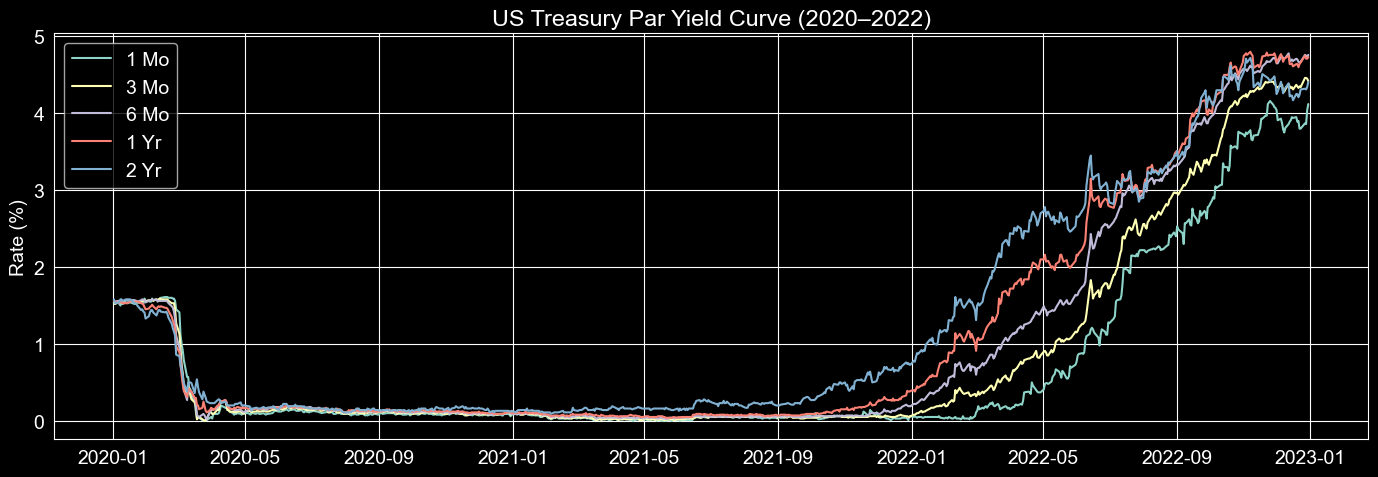

In [39]:
rate_cols = ["1 Mo", "3 Mo", "6 Mo", "1 Yr", "2 Yr"]
rate_cols_present = [c for c in rate_cols if c in df_rates.columns]

fig, ax = plt.subplots(figsize=(14, 5))
for col in rate_cols_present:
    ax.plot(df_rates["date"], df_rates[col] * 100, label=col)
ax.set_title("US Treasury Par Yield Curve (2020–2022)")
ax.set_ylabel("Rate (%)"); ax.legend(); plt.tight_layout(); plt.show()

## 8. Summary

| Metric | SPY ATM 30d | AAPL ATM 30d |
|---|---|---|
| Mean IV | ... | ... |
| Std IV  | ... | ... |
| Mean θ  | ... | ... |
| Mean Γ  | ... | ... |
| Mean ν  | ... | ... |

In [40]:
summary = pd.DataFrame({
    "SPY ATM 30d": df_spy_atm_30[["implied_volatility","theta","gamma","vega"]].mean(),
    "AAPL ATM 30d": df_aapl_atm_30[["implied_volatility","theta","gamma","vega"]].mean(),
}).T
summary.columns = ["Mean IV", "Mean θ", "Mean Γ", "Mean ν"]
summary["Mean IV"] = summary["Mean IV"] * 100
summary.round(4)

,Mean IV,Mean θ,Mean Γ,Mean ν
SPY ATM 30d,20.6752,-0.1417,0.0195,0.4441
AAPL ATM 30d,32.9830,-0.1169,0.0276,0.2139
